# Two Research Studies: Regime-Shift Robustness & Censoring Bias

Two testable hypotheses specific to this dataset's structure, not just applying known techniques:

**Study 1 -- Regime-shift robustness.** Our data spans three distinct macro regimes: 2020 COVID/low-rate, 2021 refi boom, 2022+ rate-hike environment. Does a model trained on one regime degrade when tested on a different one? And does the more complex model (LightGBM) degrade *more* than the simpler one (logistic regression) -- a classic complexity/robustness tradeoff?

**Study 2 -- Quantifying the censoring bias.** We already filter to `current_loan_age >= 24` months to avoid training on not-yet-seasoned loans. But even at 24 months, how much of a loan's *eventual* lifetime default risk has actually shown up yet? Using our fully-matured 2020-2021 cohorts (45-66 months old today), we reconstruct what their cumulative default rate looked like *when they were only 24 months old*, and compare it to their current (mature) rate -- a direct, numeric measure of how much risk is still hidden at the 24-month mark.

# STUDY 1: Regime-Shift Robustness

## Setup: seasoned loans, split by origination vintage (not randomly)

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUMERIC_FEATURES = [
    "credit_score", "original_dti", "original_upb", "original_cltv", "original_ltv",
    "original_interest_rate", "original_loan_term", "number_of_borrowers",
    "number_of_units", "mi_percent",
]
CATEGORICAL_FEATURES = [
    "occupancy_status", "property_type", "loan_purpose", "channel",
    "first_time_homebuyer_flag", "property_state",
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
BASELINE_FIELDS = ["credit_score", "original_dti", "original_upb", "original_cltv", "original_interest_rate"]
TARGET = "default_target"

DATA_GLOB = "../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet"

df = (
    pl.scan_parquet(DATA_GLOB)
    .select(ALL_FEATURES + [TARGET, "current_loan_age", "orig_year", "orig_quarter"])
    .collect()
)
seasoned = df.filter(pl.col("current_loan_age") >= 24).drop_nulls(subset=[TARGET])
print(f"Seasoned loans: {seasoned.height:,}")
print()
print("Loans per origination year (seasoned subset):")
print(seasoned.group_by("orig_year").agg(pl.len(), pl.col(TARGET).mean().alias("default_rate")).sort("orig_year"))

Seasoned loans: 8,735,702

Loans per origination year (seasoned subset):
shape: (4, 3)
┌───────────┬─────────┬──────────────┐
│ orig_year ┆ len     ┆ default_rate │
│ ---       ┆ ---     ┆ ---          │
│ i32       ┆ u32     ┆ f64          │
╞═══════════╪═════════╪══════════════╡
│ 2020      ┆ 3016648 ┆ 0.019857     │
│ 2021      ┆ 3715486 ┆ 0.019228     │
│ 2022      ┆ 1441300 ┆ 0.028384     │
│ 2023      ┆ 562268  ┆ 0.017983     │
└───────────┴─────────┴──────────────┘


## Split by vintage: train 2020-2021, test same-regime (held-out) vs. out-of-regime (2022-2023)

Seasoned data runs 2020Q1-2023Q3. `TRAIN` = 2020-2021 (COVID/low-rate regime), split 80/20 for an in-regime test set. `OUT_OF_REGIME` = 2022-2023 (rate-hike regime) -- the model never sees this during training.

In [2]:
from sklearn.model_selection import train_test_split

pdf = seasoned.select(ALL_FEATURES + [TARGET, "orig_year"]).to_pandas()
for c in CATEGORICAL_FEATURES:
    pdf[c] = pdf[c].astype("category")

regime_2020_21 = pdf[pdf["orig_year"].isin([2020, 2021])]
regime_2022_23 = pdf[pdf["orig_year"].isin([2022, 2023])]

X_train, X_test_same, y_train, y_test_same = train_test_split(
    regime_2020_21[ALL_FEATURES], regime_2020_21[TARGET],
    test_size=0.2, random_state=42, stratify=regime_2020_21[TARGET],
)
X_test_shift = regime_2022_23[ALL_FEATURES]
y_test_shift = regime_2022_23[TARGET]

print(f"Train (2020-2021):          {len(X_train):,}  default rate {y_train.mean():.4%}")
print(f"Test, same regime (2020-21): {len(X_test_same):,}  default rate {y_test_same.mean():.4%}")
print(f"Test, out-of-regime (2022-23): {len(X_test_shift):,}  default rate {y_test_shift.mean():.4%}")

Train (2020-2021):          5,385,707  default rate 1.9510%
Test, same regime (2020-21): 1,346,427  default rate 1.9510%
Test, out-of-regime (2022-23): 2,003,568  default rate 2.5465%


## Train both models on 2020-2021 only, evaluate on both test sets

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

# --- Logistic regression (5 fields) ---
logit = make_pipeline(
    SimpleImputer(strategy="median"),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
logit.fit(X_train[BASELINE_FIELDS], y_train)

logit_same_proba = logit.predict_proba(X_test_same[BASELINE_FIELDS])[:, 1]
logit_shift_proba = logit.predict_proba(X_test_shift[BASELINE_FIELDS])[:, 1]

# --- LightGBM (16 fields) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
gbm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1,
)
gbm.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)

gbm_same_proba = gbm.predict_proba(X_test_same)[:, 1]
gbm_shift_proba = gbm.predict_proba(X_test_shift)[:, 1]

def report(name, y_true, proba):
    roc = roc_auc_score(y_true, proba)
    pr = average_precision_score(y_true, proba)
    print(f"{name:45s} ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}")
    return roc, pr

print("=== Logistic Regression (5 fields) ===")
logit_roc_same, logit_pr_same = report("  Same-regime test (2020-21 held-out)", y_test_same, logit_same_proba)
logit_roc_shift, logit_pr_shift = report("  Out-of-regime test (2022-23)", y_test_shift, logit_shift_proba)
print(f"  --> ROC-AUC drop: {logit_roc_same - logit_roc_shift:+.4f}   PR-AUC drop: {logit_pr_same - logit_pr_shift:+.4f}")
print()
print("=== LightGBM (16 fields) ===")
gbm_roc_same, gbm_pr_same = report("  Same-regime test (2020-21 held-out)", y_test_same, gbm_same_proba)
gbm_roc_shift, gbm_pr_shift = report("  Out-of-regime test (2022-23)", y_test_shift, gbm_shift_proba)
print(f"  --> ROC-AUC drop: {gbm_roc_same - gbm_roc_shift:+.4f}   PR-AUC drop: {gbm_pr_same - gbm_pr_shift:+.4f}")

=== Logistic Regression (5 fields) ===


  Same-regime test (2020-21 held-out)         ROC-AUC=0.7788  PR-AUC=0.0708


  Out-of-regime test (2022-23)                ROC-AUC=0.6785  PR-AUC=0.0499
  --> ROC-AUC drop: +0.1003   PR-AUC drop: +0.0209

=== LightGBM (16 fields) ===


  Same-regime test (2020-21 held-out)         ROC-AUC=0.8036  PR-AUC=0.0850


  Out-of-regime test (2022-23)                ROC-AUC=0.7264  PR-AUC=0.0555
  --> ROC-AUC drop: +0.0771   PR-AUC drop: +0.0295


## Calibration under regime shift

Does a predicted 5% risk still mean ~5% observed default when tested out-of-regime, or does the model become systematically over/under-confident?

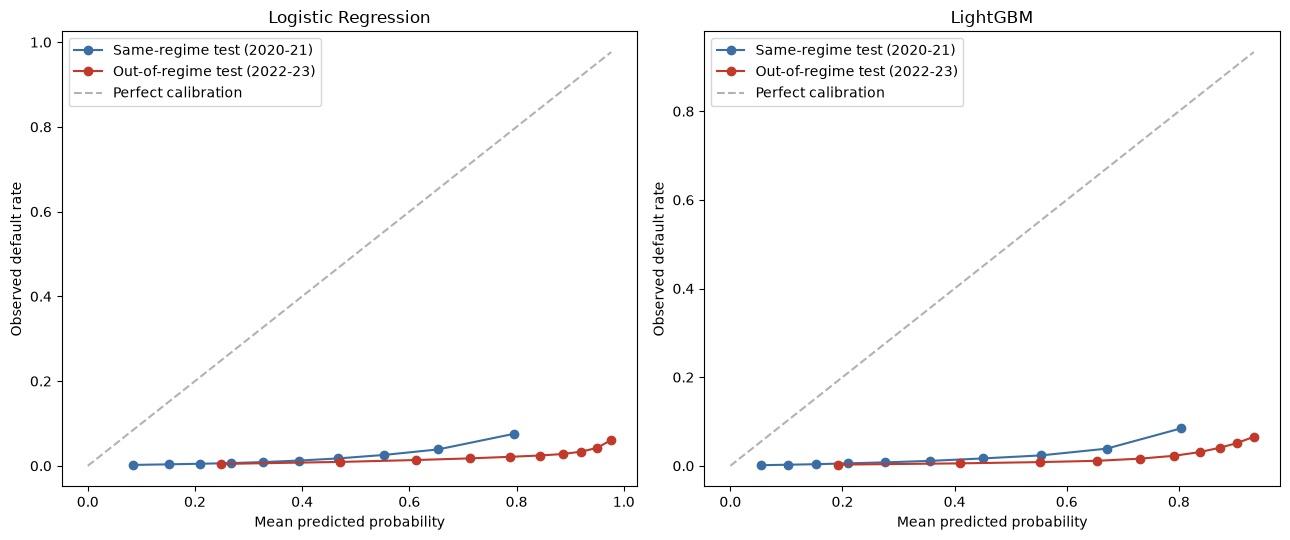

In [4]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (name, same_proba, shift_proba, y_s, y_sh) in zip(
    axes,
    [
        ("Logistic Regression", logit_same_proba, logit_shift_proba, y_test_same, y_test_shift),
        ("LightGBM", gbm_same_proba, gbm_shift_proba, y_test_same, y_test_shift),
    ],
):
    frac_pos_same, mean_pred_same = calibration_curve(y_s, same_proba, n_bins=10, strategy="quantile")
    frac_pos_shift, mean_pred_shift = calibration_curve(y_sh, shift_proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred_same, frac_pos_same, "o-", color="#3b6ea5", label="Same-regime test (2020-21)")
    ax.plot(mean_pred_shift, frac_pos_shift, "o-", color="#c0392b", label="Out-of-regime test (2022-23)")
    ax.plot([0, max(mean_pred_shift.max(), mean_pred_same.max())],
            [0, max(mean_pred_shift.max(), mean_pred_same.max())], "k--", alpha=0.3, label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed default rate")
    ax.set_title(name)
    ax.legend()

fig.tight_layout()
plt.show()

# STUDY 2: Quantifying the Censoring Bias

## Reconstruct each loan's age-at-first-default from the monthly performance panel

For the fully-matured 2020-2021 cohorts (45-66 months old today), find the exact loan age at which each loan first hit our default definition (90+ days delinquent, "RA" status, or an adverse zero-balance code). Processed per part-file (bounded chunks, same pattern as the pipeline) since the monthly panel for these two years alone is ~377M rows.

In [5]:
import glob as globmod

ADVERSE_ZERO_BALANCE_CODES = ["02", "03", "09", "15", "16", "96", "97", "98"]
DELINQUENT_90DPD_THRESHOLD = 3

def partial_age_at_default(part_path: str) -> pl.DataFrame:
    lf = pl.scan_parquet(part_path)
    numeric_status = pl.col("current_loan_delinquency_status").cast(pl.Int32, strict=False)
    is_default_event = (
        (numeric_status >= DELINQUENT_90DPD_THRESHOLD)
        | (pl.col("current_loan_delinquency_status") == "RA")
        | (pl.col("zero_balance_code").is_in(ADVERSE_ZERO_BALANCE_CODES))
    )
    return (
        lf.group_by("loan_sequence_number")
        .agg(
            age_at_default=pl.when(is_default_event).then(pl.col("loan_age")).otherwise(None).min(),
        )
        .collect()
    )

part_files = sorted(
    globmod.glob("../data/processed/monthly_panel/orig_year=2020/orig_quarter=*/*/part-*.parquet")
    + globmod.glob("../data/processed/monthly_panel/orig_year=2021/orig_quarter=*/*/part-*.parquet")
)
print(f"Processing {len(part_files)} part files (2020-2021 monthly panel)...")

partials = [partial_age_at_default(p) for p in part_files]
partials_df = pl.concat(partials)
print(f"Partial results (pre-merge): {partials_df.height:,} rows")

# Merge partials -- same loan can appear in multiple part-files only at chunk
# boundaries, so this final group_by is on an already-small (~loan-count-sized) table.
age_at_default = (
    partials_df.group_by("loan_sequence_number")
    .agg(age_at_default=pl.col("age_at_default").min())
)
print(f"Final per-loan age-at-default table: {age_at_default.height:,} rows")
print(f"Loans that ever defaulted (2020-2021): {age_at_default['age_at_default'].is_not_null().sum():,}")

Processing 1258 part files (2020-2021 monthly panel)...


Partial results (pre-merge): 8,011,338 rows


Final per-loan age-at-default table: 8,010,112 rows
Loans that ever defaulted (2020-2021): 160,324


## Compare: default rate as it would have looked at 24 months vs. the current (mature) rate

In [6]:
mature = (
    pl.scan_parquet(DATA_GLOB)
    .filter(pl.col("orig_year").is_in([2020, 2021]))
    .select("loan_sequence_number", "orig_year", "current_loan_age", TARGET)
    .collect()
    .join(age_at_default, on="loan_sequence_number", how="left")
)

AGE_CHECKPOINTS = [6, 12, 18, 24, 36, 48]
rows = []
for age in AGE_CHECKPOINTS:
    # only include loans that have actually been observed at least this long
    eligible = mature.filter(pl.col("current_loan_age") >= age)
    rate_at_age = (eligible["age_at_default"].fill_null(10_000) <= age).mean()
    rows.append({"age_months": age, "cumulative_default_rate": rate_at_age, "n_loans": eligible.height})

curve = pl.DataFrame(rows)
current_mature_rate = mature[TARGET].mean()

print("Cumulative default rate by loan age (2020-2021 cohorts, reconstructed from monthly panel):")
print(curve)
print()
print(f"Current (mature, ~45-66 month) default rate: {current_mature_rate:.4%}")
rate_at_24 = curve.filter(pl.col("age_months") == 24)["cumulative_default_rate"][0]
print(f"Rate that would have been observed at 24 months: {rate_at_24:.4%}")
print(f"--> At the 24-month seasoning cutoff, only {rate_at_24/current_mature_rate:.1%} of eventual defaults had shown up yet.")
print(f"--> A model trained on 24-month snapshots understates eventual default rate by {current_mature_rate - rate_at_24:.4%} (absolute), "
      f"a {(current_mature_rate/rate_at_24 - 1):.1%} relative underestimate.")

Cumulative default rate by loan age (2020-2021 cohorts, reconstructed from monthly panel):
shape: (6, 3)
┌────────────┬─────────────────────────┬─────────┐
│ age_months ┆ cumulative_default_rate ┆ n_loans │
│ ---        ┆ ---                     ┆ ---     │
│ i64        ┆ f64                     ┆ i64     │
╞════════════╪═════════════════════════╪═════════╡
│ 6          ┆ 0.004108                ┆ 7857123 │
│ 12         ┆ 0.007113                ┆ 7363881 │
│ 18         ┆ 0.00933                 ┆ 6969166 │
│ 24         ┆ 0.010835                ┆ 6732134 │
│ 36         ┆ 0.012396                ┆ 6414290 │
│ 48         ┆ 0.013039                ┆ 5092571 │
└────────────┴─────────────────────────┴─────────┘

Current (mature, ~45-66 month) default rate: 2.0015%
Rate that would have been observed at 24 months: 1.0835%
--> At the 24-month seasoning cutoff, only 54.1% of eventual defaults had shown up yet.
--> A model trained on 24-month snapshots understates eventual default rate by 0.918